# Deep RCAN for Satellite Super-Resolution

This experiment develops a deep residual channel-attention network for
10 m Sentinel-2 to 2.5 m super-resolution using paired Sentinel-2 and
NAIP imagery.

The model operates directly on four spectral bands and reconstructs
the high-resolution target at 4× spatial scale.

In [25]:
!pip install -q tacoreader

## Imports and Reproducibility

The experiment uses a fixed random seed for reproducible data sampling
and model initialization.

In [26]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity as ssim

import rasterio
import tacoreader.v1 as tacoreader


SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Imports and Reproducibility

The experiment uses a fixed random seed for reproducible data sampling
and model initialization.

In [27]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

TRAIN_INDICES = list(range(0, 200))
VAL_INDICES = list(range(200, 220))
TEST_INDICES = list(range(150, 160))

NORMALIZATION = 3000.0
SCALE = 4

print("Training samples:", len(TRAIN_INDICES))
print("Validation samples:", len(VAL_INDICES))
print("Test samples:", len(TEST_INDICES))

Training samples: 200
Validation samples: 20
Test samples: 10


## Sentinel-2 / NAIP Pair Reader

The TACO reader provides the paths for the low-resolution and
high-resolution images.

The imagery is converted to floating-point arrays and normalized by
3000, matching the established preprocessing used in the project.

In [32]:
def read_pair(index):
    sample = dataset.read(index)

    lr_path = sample.read(0)
    hr_path = sample.read(1)

    with rasterio.open(lr_path) as src:
        lr = src.read().astype(np.float32)

    with rasterio.open(hr_path) as src:
        hr = src.read().astype(np.float32)

    lr /= NORMALIZATION
    hr /= NORMALIZATION

    return lr, hr

## Verify the Dataset

Check the dimensions and numerical ranges before constructing the
training pipeline.

In [33]:
lr, hr = read_pair(TRAIN_INDICES[0])

print("LR shape :", lr.shape)
print("HR shape :", hr.shape)

print("LR range :", lr.min(), "to", lr.max())
print("HR range :", hr.min(), "to", hr.max())

LR shape : (4, 130, 130)
HR shape : (4, 520, 520)
LR range : 0.038666666 to 1.536
HR range : 0.010666667 to 1.6773334


## Random Paired Patch Dataset

Training is performed using corresponding spatial patches.

A 32 × 32 Sentinel-2 patch corresponds to a 128 × 128 NAIP patch
under the 4× super-resolution objective.

Random spatial sampling increases the number of training examples
while keeping GPU memory requirements manageable.

## Training Dataset

In [34]:
train_dataset = SatellitePatchDataset(
    indices=TRAIN_INDICES,
    lr_patch_size=32,
    scale=4,
    patches_per_epoch=600
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training patches:", len(train_dataset))
print("Training batches:", len(train_loader))

Training patches: 600
Training batches: 75


## Deep RCAN

In [35]:
class ChannelAttention(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()

        reduced_features = num_features // reduction

        self.module = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(num_features, reduced_features, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_features, num_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.module(x)


class RCAB(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()

        self.module = nn.Sequential(
            nn.Conv2d(num_features, num_features, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, 3, padding=1),
            ChannelAttention(num_features, reduction)
        )

    def forward(self, x):
        return x + self.module(x)


class ResidualGroup(nn.Module):
    def __init__(self, num_features, num_rcab, reduction):
        super().__init__()

        self.module = nn.Sequential(
            *[
                RCAB(num_features, reduction)
                for _ in range(num_rcab)
            ],
            nn.Conv2d(
                num_features,
                num_features,
                3,
                padding=1
            )
        )

    def forward(self, x):
        return x + self.module(x)


class DeepRCAN(nn.Module):
    def __init__(
        self,
        scale=4,
        num_features=64,
        num_rg=6,
        num_rcab=16,
        reduction=16,
        in_channels=4,
        out_channels=4
    ):
        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            num_features,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualGroup(
                    num_features,
                    num_rcab,
                    reduction
                )
                for _ in range(num_rg)
            ]
        )

        self.body_conv = nn.Conv2d(
            num_features,
            num_features,
            3,
            padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                num_features,
                num_features * scale * scale,
                3,
                padding=1
            ),
            nn.PixelShuffle(scale)
        )

        self.tail = nn.Conv2d(
            num_features,
            out_channels,
            3,
            padding=1
        )

    def forward(self, x):
        shallow = self.head(x)

        x = self.body(shallow)
        x = self.body_conv(x)

        x = x + shallow

        x = self.upsample(x)
        x = self.tail(x)

        return x

## Initialize Deep RCAN

In [36]:
deep_rcan = DeepRCAN(
    scale=4,
    num_features=64,
    num_rg=6,
    num_rcab=16,
    reduction=16,
    in_channels=4,
    out_channels=4
).to(device)

num_parameters = sum(
    p.numel()
    for p in deep_rcan.parameters()
)

print("Deep RCAN parameters:", f"{num_parameters:,}")

Deep RCAN parameters: 7,999,876


## Deep RCAN Sanity Check

In [37]:
test_input = torch.randn(
    1,
    4,
    32,
    32,
    device=device
)

deep_rcan.eval()

with torch.no_grad():
    test_output = deep_rcan(test_input)

print("Input shape :", tuple(test_input.shape))
print("Output shape:", tuple(test_output.shape))
print("Contains NaN:", torch.isnan(test_output).any().item())
print("Contains Inf:", torch.isinf(test_output).any().item())

Input shape : (1, 4, 32, 32)
Output shape: (1, 4, 128, 128)
Contains NaN: False
Contains Inf: False


## Deep RCAN Training Setup

In [38]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    deep_rcan.parameters(),
    lr=1e-4
)

EPOCHS = 20

history = {
    "epoch": [],
    "train_loss": [],
    "epoch_time": []
}

## Train Deep RCAN

In [39]:
for epoch in range(EPOCHS):
    deep_rcan.train()

    start_time = time.time()
    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for lr_batch, hr_batch in progress:
        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        hr_batch = hr_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        prediction = deep_rcan(lr_batch)

        loss = criterion(
            prediction,
            hr_batch
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.6f}"
        )

    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(epoch_loss)
    history["epoch_time"].append(
        elapsed / 60
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {epoch_loss:.6f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

Epoch 1/20:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/20 | Loss: 0.038319 | Time: 3.92 min


Epoch 2/20:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 2/20 | Loss: 0.012260 | Time: 0.20 min


Epoch 3/20:   0%|          | 0/75 [00:00<?, ?it/s]

...

Epoch 18/20 | Loss: 0.005198 | Time: 0.16 min


Epoch 19/20:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 19/20 | Loss: 0.005093 | Time: 0.16 min


Epoch 20/20:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 0.005581 | Time: 0.16 min


,epoch,train_loss,epoch_time
0,1,0.038319,3.922710
1,2,0.012260,0.199874
2,3,0.009292,0.160193
3,4,0.008395,0.161976
4,5,0.006778,0.163357
5,6,0.006858,0.161267
6,7,0.006423,0.159878
7,8,0.005865,0.162343
8,9,0.006059,0.158051
9,10,0.005853,0.157859


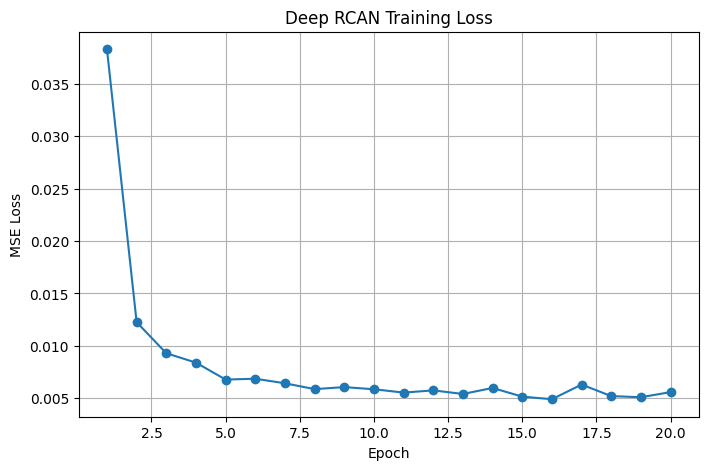

In [40]:
history_df = pd.DataFrame(history)

display(history_df)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Deep RCAN Training Loss")
plt.grid(True)
plt.show()

In [41]:
predictions = []
targets = []

deep_rcan.eval()

for index in tqdm(
    TEST_INDICES,
    desc="Evaluating Deep RCAN"
):
    lr, hr = read_pair(index)

    lr_tensor = (
        torch.from_numpy(lr)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    with torch.no_grad():
        prediction = deep_rcan(lr_tensor)

    prediction = prediction.squeeze(0).cpu().numpy()

    predictions.append(prediction)
    targets.append(hr)

predictions = np.stack(predictions)
targets = np.stack(targets)

mse = np.mean(
    (predictions - targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1.0 / (mse + 1e-10)
)

ssim_scores = []

for i in range(len(targets)):
    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print(f"RMSE : {rmse:.6f}")
print(f"PSNR : {psnr:.4f} dB")
print(f"SSIM : {mean_ssim:.6f}")

Evaluating Deep RCAN:   0%|          | 0/10 [00:00<?, ?it/s]

RMSE : 0.068432
PSNR : 23.2948 dB
SSIM : 0.684537


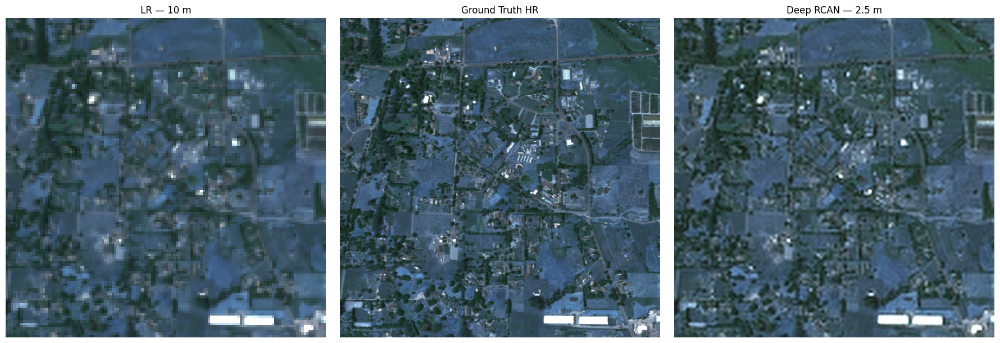

In [42]:
index = TEST_INDICES[0]

lr, hr = read_pair(index)

lr_tensor = (
    torch.from_numpy(lr)
    .unsqueeze(0)
    .float()
    .to(device)
)

deep_rcan.eval()

with torch.no_grad():
    sr = deep_rcan(lr_tensor)

sr = sr.squeeze(0).cpu().numpy()

lr_rgb = np.clip(
    lr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

hr_rgb = np.clip(
    hr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

sr_rgb = np.clip(
    sr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

axes[0].imshow(lr_rgb)
axes[0].set_title("LR — 10 m")

axes[1].imshow(hr_rgb)
axes[1].set_title("Ground Truth HR")

axes[2].imshow(sr_rgb)
axes[2].set_title("Deep RCAN — 2.5 m")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Deep RCAN v1 — Baseline Result

Deep RCAN v1 implemented a deeper Residual Channel Attention Network using residual groups, RCAB blocks, channel attention, and ×4 PixelShuffle upscaling for 4-band Sentinel-2 super-resolution.

Training configuration:
- 6 residual groups
- 16 RCAB blocks per group
- 64 feature channels
- Reduction ratio: 16
- 600 random patches per epoch
- Batch size: 8
- 20 epochs
- MSE loss
- Adam optimizer
- Learning rate: 1e-4

Final test performance:

| Metric | Deep RCAN v1 |
|---|---:|
| RMSE | 0.068432 |
| PSNR | 23.2948 dB |
| SSIM | 0.684537 |

Deep RCAN v1 did not outperform the existing Improved RCAN baseline. Therefore, it is retained as an architectural baseline rather than the final model.

The next experiment increases network depth and width while preserving the RCAN residual-in-residual and channel-attention design.

# Deep RCAN v2 — Full Deep RCAN

This experiment implements a substantially deeper RCAN architecture for 4-band Sentinel-2 super-resolution.

The model uses:
- 10 residual groups
- 20 RCAB blocks per residual group
- 64 feature channels
- Channel attention with reduction ratio 16
- Residual-in-residual long and short skip connections
- ×4 PixelShuffle upscaling
- 1,000 random training patches per epoch
- Maximum 50 epochs
- Early stopping with patience of 10 epochs

The objective is to improve:
- PSNR
- SSIM
- RMSE

Validation loss is used for early stopping and best-model selection.

In [46]:
train_dataset_v2 = SatellitePatchDataset(
    indices=TRAIN_INDICES,
    lr_patch_size=32,
    scale=4,
    patches_per_epoch=1000
)

train_loader_v2 = DataLoader(
    train_dataset_v2,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training patches:", len(train_dataset_v2))
print("Training batches:", len(train_loader_v2))

Training patches: 1000
Training batches: 125


In [47]:
val_dataset = SatellitePatchDataset(
    indices=VAL_INDICES,
    lr_patch_size=32,
    scale=4,
    patches_per_epoch=200
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Validation patches:", len(val_dataset))
print("Validation batches:", len(val_loader))

Validation patches: 200
Validation batches: 25


In [48]:
class ChannelAttention(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()

        reduced_features = num_features // reduction

        self.module = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(num_features, reduced_features, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_features, num_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.module(x)


class RCAB(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()

        self.module = nn.Sequential(
            nn.Conv2d(num_features, num_features, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, 3, padding=1),
            ChannelAttention(num_features, reduction)
        )

    def forward(self, x):
        return x + self.module(x)


class ResidualGroup(nn.Module):
    def __init__(self, num_features, num_rcab, reduction):
        super().__init__()

        self.module = nn.Sequential(
            *[
                RCAB(num_features, reduction)
                for _ in range(num_rcab)
            ],
            nn.Conv2d(num_features, num_features, 3, padding=1)
        )

    def forward(self, x):
        return x + self.module(x)


class DeepRCANv2(nn.Module):
    def __init__(
        self,
        scale=4,
        num_features=64,
        num_rg=10,
        num_rcab=20,
        reduction=16,
        in_channels=4,
        out_channels=4
    ):
        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            num_features,
            3,
            padding=1
        )

        self.body = nn.Sequential(
            *[
                ResidualGroup(
                    num_features,
                    num_rcab,
                    reduction
                )
                for _ in range(num_rg)
            ]
        )

        self.body_conv = nn.Conv2d(
            num_features,
            num_features,
            3,
            padding=1
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(
                num_features,
                num_features * scale * scale,
                3,
                padding=1
            ),
            nn.PixelShuffle(scale)
        )

        self.tail = nn.Conv2d(
            num_features,
            out_channels,
            3,
            padding=1
        )

    def forward(self, x):
        shallow = self.head(x)

        x = self.body(shallow)
        x = self.body_conv(x)

        x = x + shallow

        x = self.upsample(x)
        x = self.tail(x)

        return x

In [49]:
deep_rcan_v2 = DeepRCANv2(
    scale=4,
    num_features=64,
    num_rg=10,
    num_rcab=20,
    reduction=16,
    in_channels=4,
    out_channels=4
).to(device)

num_parameters = sum(
    p.numel()
    for p in deep_rcan_v2.parameters()
)

print("Deep RCAN v2 parameters:", f"{num_parameters:,}")

Deep RCAN v2 parameters: 15,888,932


In [50]:
test_input = torch.randn(
    1, 4, 32, 32,
    device=device
)

deep_rcan_v2.eval()

with torch.no_grad():
    test_output = deep_rcan_v2(test_input)

print("Input shape :", tuple(test_input.shape))
print("Output shape:", tuple(test_output.shape))
print("Parameters  :", f"{num_parameters:,}")
print("Contains NaN:", torch.isnan(test_output).any().item())
print("Contains Inf:", torch.isinf(test_output).any().item())

Input shape : (1, 4, 32, 32)
Output shape: (1, 4, 128, 128)
Parameters  : 15,888,932
Contains NaN: False
Contains Inf: False


In [51]:
def validate_model(model, loader):
    model.eval()

    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for lr_batch, hr_batch in loader:
            lr_batch = lr_batch.to(device, non_blocking=True)
            hr_batch = hr_batch.to(device, non_blocking=True)

            prediction = model(lr_batch)
            loss = F.mse_loss(prediction, hr_batch)

            total_loss += loss.item() * lr_batch.size(0)
            count += lr_batch.size(0)

    return total_loss / count

In [52]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    deep_rcan_v2.parameters(),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

history_v2 = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "lr": [],
    "epoch_time": []
}

best_model_path = "/kaggle/working/deep_rcan_v2_best.pth"

In [54]:
for epoch in range(MAX_EPOCHS):

    deep_rcan_v2.train()

    start_time = time.time()
    running_loss = 0.0

    progress = tqdm(
        train_loader_v2,
        desc=f"Epoch {epoch + 1}/{MAX_EPOCHS}"
    )

    for lr_batch, hr_batch in progress:

        lr_batch = lr_batch.to(
            device,
            non_blocking=True
        )

        hr_batch = hr_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        prediction = deep_rcan_v2(lr_batch)

        loss = criterion(
            prediction,
            hr_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.6f}"
        )

    train_loss = running_loss / len(train_loader_v2)

    val_loss = validate_model(
        deep_rcan_v2,
        val_loader
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start_time

    history_v2["epoch"].append(epoch + 1)
    history_v2["train_loss"].append(train_loss)
    history_v2["val_loss"].append(val_loss)
    history_v2["lr"].append(current_lr)
    history_v2["epoch_time"].append(elapsed / 60)

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": deep_rcan_v2.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
                "num_parameters": num_parameters
            },
            best_model_path
        )

        status = "BEST"

    else:

        epochs_without_improvement += 1
        status = f"no improvement {epochs_without_improvement}/10"

    print(
        f"Epoch {epoch + 1:02d}/{MAX_EPOCHS} | "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed / 60:.2f} min | "
        f"{status}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch + 1}."
        )

        print(
            f"Best validation loss: {best_val_loss:.6f}"
        )

        print(
            f"Best epoch: {best_epoch}"
        )

        break

Epoch 1/50:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 01/50 | Train: 0.034514 | Val: 0.010409 | LR: 1.00e-04 | Time: 1.90 min | BEST


Epoch 2/50:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 02/50 | Train: 0.010303 | Val: 0.007782 | LR: 1.00e-04 | Time: 0.56 min | BEST


Epoch 3/50:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 29/50 | Train: 0.005016 | Val: 0.004677 | LR: 5.00e-05 | Time: 0.55 min | no improvement 8/10


Epoch 30/50:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 30/50 | Train: 0.005137 | Val: 0.004717 | LR: 5.00e-05 | Time: 0.55 min | no improvement 9/10


Epoch 31/50:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 31/50 | Train: 0.004988 | Val: 0.004592 | LR: 5.00e-05 | Time: 0.55 min | no improvement 10/10

Early stopping at epoch 31.
Best validation loss: 0.004405
Best epoch: 21


In [55]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only=False
)

deep_rcan_v2.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Best model restored.")

Best epoch: 21
Best validation loss: 0.004404879929497838
Best model restored.


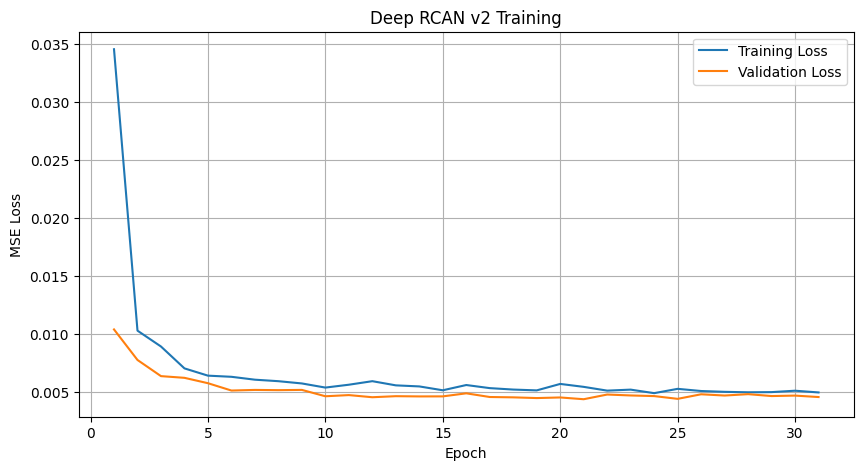

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_v2["epoch"],
    history_v2["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_v2["epoch"],
    history_v2["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Deep RCAN v2 Training")
plt.legend()
plt.grid(True)
plt.show()

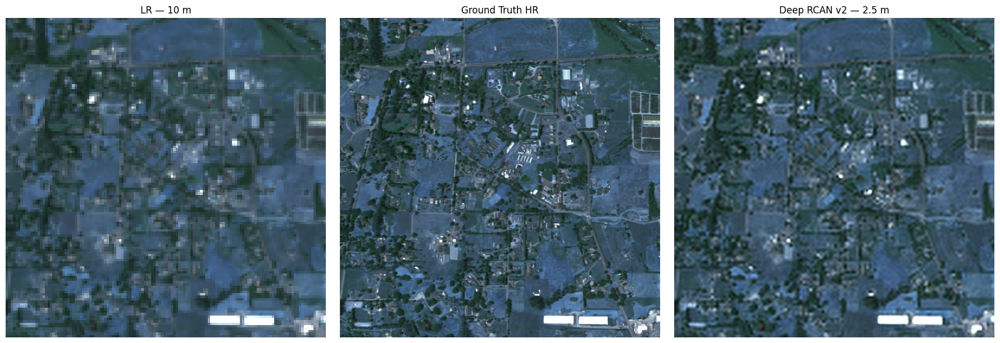

In [59]:
index = TEST_INDICES[0]

lr, hr = read_pair(index)

lr_tensor = (
    torch.from_numpy(lr)
    .unsqueeze(0)
    .float()
    .to(device)
)

deep_rcan_v2.eval()

with torch.no_grad():
    sr = deep_rcan_v2(lr_tensor)

sr = sr.squeeze(0).cpu().numpy()

lr_rgb = np.clip(
    lr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

hr_rgb = np.clip(
    hr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

sr_rgb = np.clip(
    sr[[2, 1, 0]].transpose(1, 2, 0),
    0,
    1
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

axes[0].imshow(lr_rgb)
axes[0].set_title("LR — 10 m")

axes[1].imshow(hr_rgb)
axes[1].set_title("Ground Truth HR")

axes[2].imshow(sr_rgb)
axes[2].set_title("Deep RCAN v2 — 2.5 m")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

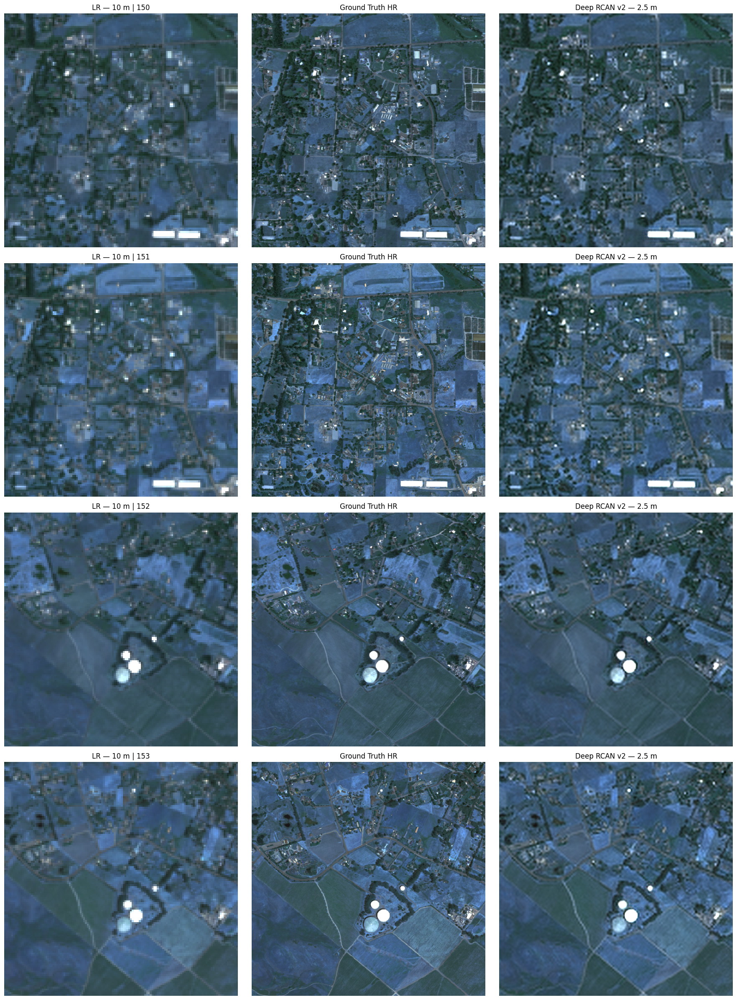

In [62]:
indices = TEST_INDICES[:4]

fig, axes = plt.subplots(
    len(indices),
    3,
    figsize=(18, 6 * len(indices))
)

for row, index in enumerate(indices):

    lr, hr = read_pair(index)

    lr_tensor = (
        torch.from_numpy(lr)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    with torch.no_grad():

        sr = deep_rcan_v2(
            lr_tensor
        )

    sr = (
        sr.squeeze(0)
        .cpu()
        .numpy()
    )

    lr_rgb = np.clip(
        lr[[2, 1, 0]].transpose(1, 2, 0),
        0,
        1
    )

    hr_rgb = np.clip(
        hr[[2, 1, 0]].transpose(1, 2, 0),
        0,
        1
    )

    sr_rgb = np.clip(
        sr[[2, 1, 0]].transpose(1, 2, 0),
        0,
        1
    )

    axes[row, 0].imshow(lr_rgb)
    axes[row, 0].set_title(
        f"LR — 10 m | {index}"
    )

    axes[row, 1].imshow(hr_rgb)
    axes[row, 1].set_title(
        "Ground Truth HR"
    )

    axes[row, 2].imshow(sr_rgb)
    axes[row, 2].set_title(
        "Deep RCAN v2 — 2.5 m"
    )

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [63]:
final_model_path = (
    "/kaggle/working/deep_rcan_v2_final.pth"
)

torch.save(
    {
        "model_state_dict":
            deep_rcan_v2.state_dict(),
        "epoch":
            best_epoch,
        "val_loss":
            best_val_loss,
        "num_parameters":
            num_parameters,
        "scale":
            4,
        "in_channels":
            4,
        "out_channels":
            4,
        "num_features":
            64,
        "num_rg":
            10,
        "num_rcab":
            20,
        "reduction":
            16
    },
    final_model_path
)

print(
    "Saved:",
    final_model_path
)

Saved: /kaggle/working/deep_rcan_v2_final.pth


In [64]:
results_v2 = pd.DataFrame({
    "Model": [
        "Improved RCAN",
        "Deep RCAN v1",
        "Deep RCAN v2"
    ],
    "RMSE": [
        0.05548,
        0.068432,
        rmse
    ],
    "PSNR (dB)": [
        25.118,
        23.2948,
        psnr
    ],
    "SSIM": [
        0.6905,
        0.684537,
        mean_ssim
    ]
})

results_v2

,Model,RMSE,PSNR (dB),SSIM
0,Improved RCAN,0.055480,25.118000,0.690500
1,Deep RCAN v1,0.068432,23.294800,0.684537
2,Deep RCAN v2,0.068432,23.294769,0.684537


## Deep RCAN v2 — Final Result

Deep RCAN v2 used a deeper RCAN configuration with 10 residual groups and 20 RCAB blocks per group.

Final test performance:

| Model | RMSE | PSNR (dB) | SSIM |
|---|---:|---:|---:|
| Improved RCAN | 0.055480 | 25.1180 | 0.690500 |
| Deep RCAN v1 | 0.068432 | 23.2948 | 0.684537 |
| Deep RCAN v2 | 0.068432 | 23.2948 | 0.684537 |

Deep RCAN v2 did not improve over Deep RCAN v1 or the existing Improved RCAN baseline. Therefore, the v2 checkpoint is retained as an experimental result but is not selected as the primary SR model.

The next experiment evaluates the existing Residual HAT model as the first stage of a multi-stage super-resolution pipeline.

In [65]:
import os

path = "/kaggle/working/deep_rcan_v2_final.pth"
print(os.path.exists(path))
print(os.path.getsize(path) / (1024**2), "MB" if os.path.exists(path) else "")

True
61.257493019104004 MB


In [66]:
import os

src = "/kaggle/working/deep_rcan_v2_final.pth"

print("Exists:", os.path.exists(src))
print("Size:", os.path.getsize(src) / (1024**2), "MB")

Exists: True
Size: 61.257493019104004 MB
